# F09 · EDA de `fraud_dataset.csv` (exploración)

Notebook de exploración: puede ser desprolijo. Las figuras para la presentación salen de
`python -m analysis.ej1_eda` y las conclusiones quedan en `docs/datos/fraud_dataset.md`.
**No se entrena nada acá.**

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd()
while not (root / "CLAUDE.md").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

In [2]:
from analysis import ej1_eda as eda

df = eda.read_fraud("datasets/fraud_dataset.csv")
P, Y = eda.TARGET, eda.LABEL
FEATS = list(eda.RAW_FEATURES)
df.shape

(7500, 11)

## 1–2. Documentación, tipos y rangos
El PDF de la cátedra solo da significado para `timestamp`, `amount_usd`, `quantity_purchased`, `big_model_fraud_probability` y `flagged_fraud`; del resto da tipo y unidad.

In [3]:
df.head()

,timestamp,amount_usd,quantity_purchased,session_duration_seconds,days_since_last_purchase,account_age_days,device_screen_resolution,time_since_last_login_s,items_viewed_before_purchase,big_model_fraud_probability,flagged_fraud
0,1726079771,42.07,5,422.6,1.61,830,8297586,1591.0,9,0.399304,0
1,1712136533,35.05,6,384.7,23.44,2993,3682826,4097.6,10,0.026173,0
2,1703558249,1.43,8,519.5,34.07,2354,1034996,2534.0,5,0.080938,0
3,1704576488,100.00,4,51.1,0.57,85,8297645,2458.9,23,0.926975,1
4,1728790505,51.51,1,278.0,5.31,1989,1044536,2774.4,12,0.281695,0


In [4]:
eda.ranges_table(df).round(3)

,tipo,min,p1,p50,p99,max,media,desvio,asimetria,unicos
timestamp,entera,1.700002e+09,1.700345e+09,1.715683e+09,1.731200e+09,1.731534e+09,1.715784e+09,9162462.018,0.012,7499
amount_usd,continua,1.000000e+00,1.000000e+00,6.349000e+01,8.580470e+02,2.000000e+03,1.090710e+02,157.747,4.535,6020
quantity_purchased,entera,1.000000e+00,1.000000e+00,5.000000e+00,2.200000e+01,2.400000e+01,5.855000e+00,4.140,1.808,24
session_duration_seconds,continua,5.000000e+00,1.000000e+01,2.870000e+02,5.718010e+02,7.268000e+02,2.801890e+02,135.958,-0.065,3919
days_since_last_purchase,continua,0.000000e+00,9.000000e-02,8.590000e+00,6.712000e+01,1.423200e+02,1.370300e+01,14.927,2.128,3130
account_age_days,entera,1.000000e+00,1.900000e+01,1.633500e+03,3.615000e+03,3.649000e+03,1.664800e+03,1122.779,0.102,3129
device_screen_resolution,entera,1.006733e+06,1.015589e+06,2.073158e+06,8.302524e+06,8.310940e+06,3.175686e+06,2682003.543,1.121,7209
time_since_last_login_s,continua,1.000000e+01,3.869500e+01,2.477700e+03,1.597706e+04,4.016080e+04,3.589363e+03,3565.243,2.056,7125
items_viewed_before_purchase,entera,1.000000e+00,1.000000e+00,8.000000e+00,2.700000e+01,2.900000e+01,8.613000e+00,5.397,1.039,29
big_model_fraud_probability,continua,1.000000e-03,1.400000e-02,3.570000e-01,1.000000e+00,1.000000e+00,4.230000e-01,0.302,0.491,7356


## 3. Composición: balance y distribución del target

In [5]:
df[Y].value_counts(), df[Y].mean().round(4)

(flagged_fraud
 0    6631
 1     869
 Name: count, dtype: int64,
 np.float64(0.1159))

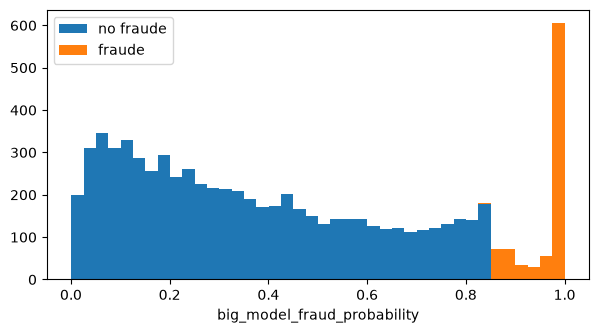

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
parts = [df.loc[df[Y] == k, P] for k in (0, 1)]
ax.hist(parts, bins=40, stacked=True, label=["no fraude", "fraude"])
ax.legend()
ax.set_xlabel(P)
plt.show()

In [7]:
df.groupby(Y)[P].describe()

,count,mean,std,min,25%,50%,75%,max
flagged_fraud,,,,,,,,
0,6631.0,0.351260,0.242961,0.000897,0.139792,0.304020,0.539503,0.849891
1,869.0,0.968567,0.047196,0.850089,0.955770,0.995675,0.999579,1.000000


## 4. Limpieza: NaN, duplicados, valores imposibles, *spikes*

In [8]:
print("NaN:", df.isna().sum().sum())
print("duplicados:", df.duplicated().sum())
print("duplicados sin target/etiqueta:", df[FEATS].duplicated().sum())
print("negativos en features:", (df[FEATS] < 0).sum().sum())
print("target fuera de [0, 1]:", ((df[P] < 0) | (df[P] > 1)).sum())

NaN: 0
duplicados: 0
duplicados sin target/etiqueta: 0
negativos en features: 0
target fuera de [0, 1]: 0


In [9]:
pd.DataFrame(eda.spikes(df))

,columna,valor,n,tasa_positivos,prob_media
0,amount_usd,100.0,156,0.987179,0.946693
1,amount_usd,1.0,82,0.000000,0.210543
2,session_duration_seconds,5.0,64,1.000000,0.983164
3,session_duration_seconds,10.0,53,0.037736,0.481900


Valores exactos repetidos en variables continuas: `amount_usd == 100` es casi siempre fraude y `session_duration_seconds == 5` siempre. `amount_usd == 1` y `session == 10` parecen mínimos recortados (clip).

## 5. Features conflictivas
### `timestamp`

In [10]:
t = pd.to_datetime(df["timestamp"], unit="s")
print(t.min(), "→", t.max())
tmp = df.assign(hora=t.dt.hour, dia=t.dt.dayofweek, mes=t.dt.to_period("M"))
for g in ("hora", "dia", "mes"):
    rango = tmp.groupby(g)[[P, Y]].mean().agg(["min", "max"]).round(3)
    print(g, rango.to_dict())

2023-11-14 22:43:28 → 2024-11-13 21:43:42
hora {'big_model_fraud_probability': {'min': 0.397, 'max': 0.457}, 'flagged_fraud': {'min': 0.098, 'max': 0.138}}
dia {'big_model_fraud_probability': {'min': 0.412, 'max': 0.439}, 'flagged_fraud': {'min': 0.103, 'max': 0.131}}
mes {'big_model_fraud_probability': {'min': 0.391, 'max': 0.449}, 'flagged_fraud': {'min': 0.091, 'max': 0.139}}


### `device_screen_resolution`: 5 resoluciones + ruido

In [11]:
res = eda.resolution_clusters(df["device_screen_resolution"].to_numpy())
print(res["desvio_px"].describe().round(1))
df.groupby(res["resolucion"].to_numpy())[[P, Y]].agg(["mean", "size"]).round(3)

count     7500.0
mean       -47.7
std       5011.9
min     -17988.0
25%      -3368.2
50%        -84.5
75%       3325.0
max      21635.0
Name: desvio_px, dtype: float64


big_model_fraud_probability       flagged_fraud      
                                 mean  size          mean  size
1280x800                        0.406  1523         0.106  1523
1366x768                        0.417  1507         0.105  1507
1920x1080                       0.439  1522         0.129  1522
2560x1440                       0.414  1504         0.118  1504
3840x2160                       0.438  1444         0.123  1444

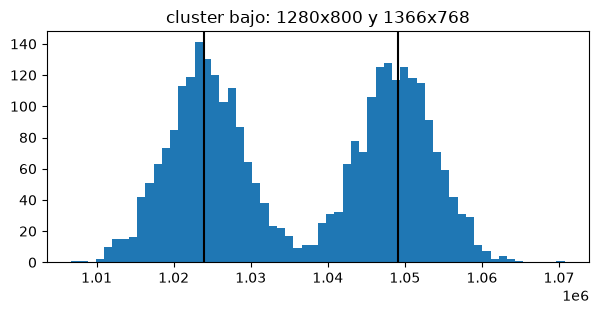

In [12]:
low = df.loc[df["device_screen_resolution"] < 1.2e6, "device_screen_resolution"]
plt.figure(figsize=(7, 3))
plt.hist(low, bins=60)
for px in (1024000, 1049088):
    plt.axvline(px, c="k")
plt.title("cluster bajo: 1280x800 y 1366x768")
plt.show()

### Asimetría (candidatas a log)

In [13]:
df[FEATS].skew().round(2).sort_values()

session_duration_seconds       -0.07
timestamp                       0.01
account_age_days                0.10
items_viewed_before_purchase    1.04
device_screen_resolution        1.12
quantity_purchased              1.81
time_since_last_login_s         2.06
days_since_last_purchase        2.13
amount_usd                      4.53
dtype: float64

## 6. Escalas

In [14]:
df[FEATS].agg(["min", "median", "max", "std"]).T

,min,median,max,std
timestamp,1.700002e+09,1.715683e+09,1.731534e+09,9.162462e+06
amount_usd,1.000000e+00,6.349000e+01,2.000000e+03,1.577465e+02
quantity_purchased,1.000000e+00,5.000000e+00,2.400000e+01,4.139798e+00
session_duration_seconds,5.000000e+00,2.870000e+02,7.268000e+02,1.359579e+02
days_since_last_purchase,0.000000e+00,8.590000e+00,1.423200e+02,1.492676e+01
account_age_days,1.000000e+00,1.633500e+03,3.649000e+03,1.122779e+03
device_screen_resolution,1.006733e+06,2.073158e+06,8.310940e+06,2.682004e+06
time_since_last_login_s,1.000000e+01,2.477700e+03,4.016080e+04,3.565243e+03
items_viewed_before_purchase,1.000000e+00,8.000000e+00,2.900000e+01,5.396869e+00


## 7. Relación feature ↔ target

In [15]:
pd.DataFrame(
    {
        "pearson_P": df[FEATS].corrwith(df[P]),
        "spearman_P": df[FEATS].corrwith(df[P], method="spearman"),
        "pearson_flag": df[FEATS].corrwith(df[Y]),
    }
).round(3)

,pearson_P,spearman_P,pearson_flag
timestamp,0.001,0.004,-0.013
amount_usd,0.557,0.584,0.580
quantity_purchased,0.563,0.475,0.609
session_duration_seconds,-0.514,-0.461,-0.520
days_since_last_purchase,-0.404,-0.448,-0.259
account_age_days,-0.585,-0.583,-0.461
device_screen_resolution,0.025,0.029,0.015
time_since_last_login_s,0.002,0.001,-0.003
items_viewed_before_purchase,0.334,0.173,0.553


In [16]:
pd.DataFrame(eda.class_bounds(df)).T

,neg_min,neg_max,pos_min,pos_max,pos_fuera_de_rango_neg
timestamp,1.700002e+09,1.731534e+09,1.700124e+09,1.731533e+09,0.0
amount_usd,1.000000e+00,5.000000e+02,1.644000e+01,2.000000e+03,199.0
quantity_purchased,1.000000e+00,9.000000e+00,1.000000e+00,2.400000e+01,524.0
session_duration_seconds,1.000000e+01,7.268000e+02,5.000000e+00,5.056000e+02,74.0
days_since_last_purchase,0.000000e+00,1.423200e+02,0.000000e+00,3.770000e+01,0.0
account_age_days,3.000000e+01,3.649000e+03,1.000000e+00,3.436000e+03,114.0
device_screen_resolution,1.009946e+06,8.310940e+06,1.006733e+06,8.306744e+06,2.0
time_since_last_login_s,1.000000e+01,4.016080e+04,1.000000e+01,2.358210e+04,0.0
items_viewed_before_purchase,1.000000e+00,1.400000e+01,1.000000e+00,2.900000e+01,490.0


Reglas duras: con `quantity > 9`, `items_viewed > 14`, `amount > 500`, `account_age < 30` o `session < 10` la transacción **siempre** es fraude.

In [17]:
for c in ["amount_usd", "quantity_purchased", "account_age_days"]:
    display(eda.decile_profile(df, c).round(3))

,decil,desde,hasta,n,big_model_fraud_probability,flagged_fraud
0,1,1.00,9.07,750,0.235,0.000
1,2,9.13,19.90,750,0.244,0.003
2,3,19.91,32.57,750,0.261,0.000
3,4,32.58,46.75,750,0.291,0.001
4,5,46.77,63.47,750,0.325,0.005
5,6,63.51,86.05,750,0.347,0.008
6,7,86.06,109.44,750,0.512,0.227
7,8,109.46,151.21,750,0.514,0.112
8,9,151.32,238.26,750,0.630,0.188
9,10,238.40,2000.00,750,0.871,0.615


,decil,desde,hasta,n,big_model_fraud_probability,flagged_fraud
0,1,1,1,750,0.232,0.007
1,2,1,2,750,0.260,0.005
2,3,2,3,750,0.318,0.048
3,4,3,4,750,0.350,0.063
4,5,4,5,750,0.388,0.052
5,6,5,6,750,0.415,0.055
6,7,6,7,750,0.428,0.067
7,8,7,8,750,0.471,0.055
8,9,8,9,750,0.508,0.080
9,10,9,24,750,0.857,0.728


,decil,desde,hasta,n,big_model_fraud_probability,flagged_fraud
0,1,1,138,750,0.869,0.763
1,2,138,454,750,0.641,0.268
2,3,454,818,750,0.500,0.045
3,4,818,1221,750,0.418,0.024
4,5,1221,1633,750,0.400,0.015
5,6,1634,2038,750,0.369,0.020
6,7,2038,2442,750,0.328,0.008
7,8,2443,2846,750,0.275,0.009
8,9,2846,3255,750,0.225,0.005
9,10,3255,3649,750,0.204,0.001


## 8. BigModel como referencia

In [18]:
eda.separation(df), eda.bigmodel_reference(df)

({'max_negativo': 0.849891,
  'min_positivo': 0.850089,
  'separable': True,
  'corte_medio': 0.84999,
  'n_solapados': 0},
 {'roc_auc': 1.0,
  'average_precision': 1.0,
  'umbral_0.5': {'umbral': 0.5,
   'precision': 0.31646030589949015,
   'recall': 1.0},
  'umbral_corte_medio': {'umbral': 0.84999, 'precision': 1.0, 'recall': 1.0}})

`flagged_fraud` es exactamente `big_model_fraud_probability > 0.85`: BigModel separa perfecto (AUC = AP = 1).

### Estratificación del runner (cuantiles del target) vs `flagged_fraud`

In [19]:
eda.strata_balance(df).round(3)

,estrato,n,prob_min,prob_max,tasa_positivos
0,0,750,0.001,0.069,0.000
1,1,750,0.069,0.126,0.000
2,2,750,0.126,0.193,0.000
3,3,750,0.193,0.270,0.000
4,4,750,0.270,0.357,0.000
5,5,750,0.357,0.461,0.000
6,6,750,0.461,0.590,0.000
7,7,750,0.590,0.740,0.000
8,8,750,0.741,0.891,0.159
9,9,750,0.891,1.000,1.000


In [20]:
from experiments.config import load_config
from experiments.runner import load_dataset

cfg = load_config("experiments/configs/ej1/base.json")
data = load_dataset(cfg["dataset"])
data.X.shape, data.feature_names

((7500, 6),
 ['amount_usd',
  'quantity_purchased',
  'session_duration_seconds',
  'days_since_last_purchase',
  'account_age_days',
  'items_viewed_before_purchase'])